In [1]:
import pickle
import os
import urllib
import torch

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torchvision.transforms.functional as TF
from sklearn.decomposition import PCA
from scipy import signal

import sys
import os
from pathlib import Path
%load_ext autoreload
%autoreload 2
sys.path.insert(0, str(Path("../dinov3/").resolve()))

/Users/work/mambaforge/envs/pytorch/lib/python3.10/site-packages/torchvision/io/image.py:13: UserWarning: Failed to load image Python extension: 'dlopen(/Users/work/mambaforge/envs/pytorch/lib/python3.10/site-packages/torchvision/image.so, 0x0006): Symbol not found: __ZN3c1017RegisterOperatorsD1Ev
  Referenced from: <6DFB383A-E1D9-3EC6-8A60-382AF4E3C226> /Users/work/mambaforge/envs/pytorch/lib/python3.10/site-packages/torchvision/image.so
  Expected in:     <772DF335-D7CB-318F-A275-48A16B0A0CA8> /Users/work/mambaforge/envs/pytorch/lib/python3.10/site-packages/torch/lib/libtorch_cpu.dylib'If you don't plan on using image functionality from `torchvision.io`, you can ignore this warning. Otherwise, there might be something wrong with your environment. Did you have `libjpeg` or `libpng` installed before building `torchvision` from source?
  warn(


In [2]:
from dinov3.hub.backbones import dinov3_vit7b16, dinov3_vitl16
from dinov3.models.depth_model import Dinov3DepthDPT

model = Dinov3DepthDPT()

In [3]:
url = "../weights/dinov3-sat-vitl-3dep-256bin-8maxdepth-loglin.pt"
state_dict = torch.load(url, map_location="cpu")
state_dict = state_dict['model_state_dict']
for k in list(state_dict.keys()):
    if 'module.' in k:
        new_k = k.replace('module.','')
        state_dict[new_k] = state_dict.pop(k)
model.load_state_dict(state_dict, strict=False)

<All keys matched successfully>

In [9]:
from PIL import Image
import urllib
PATCH_SIZE = 16
IMAGE_SIZE = 416

MEAN = (0.430, 0.411, 0.296 )
STD = (0.213, 0.156, 0.143 )

def resize_transform(
    mask_image: Image,
    image_size: int = IMAGE_SIZE,
    patch_size: int = PATCH_SIZE,
) -> torch.Tensor:
    w, h = mask_image.size
    h_patches = int(image_size / patch_size)
    w_patches = int((w * image_size) / (h * patch_size))
    return TF.to_tensor(TF.resize(mask_image, (h_patches * patch_size, w_patches * patch_size)))


image = Image.open("test.png")

image_resized = resize_transform(image)
image_resized_norm = TF.normalize(image_resized, mean=MEAN, std=STD)

In [10]:
with torch.inference_mode():
    with torch.no_grad():
        pred = model(image_resized_norm.unsqueeze(0))

/Users/work/Documents/GitHub/dinov3_species/dinov3/dinov3/models/depth_model.py:645: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.no_grad(), torch.cuda.amp.autocast(enabled=True, dtype=torch.float16):
/Users/work/mambaforge/envs/pytorch/lib/python3.10/site-packages/torch/amp/autocast_mode.py:266: UserWarning: User provided device_type of 'cuda', but CUDA is not available. Disabling
  warnings.warn(


<Axes: >

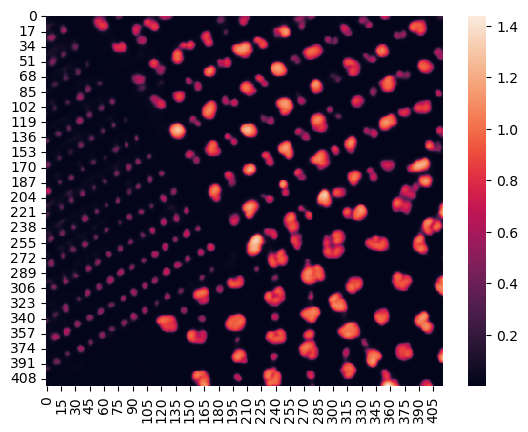

In [11]:
import seaborn as sns
sns.heatmap(pred.squeeze().cpu())